In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/protein-rnn-gru/pytorch/final/2/BiRNN.pth
/kaggle/input/protein-rnn-gru/pytorch/final/2/BiGRU.pth
/kaggle/input/protein-cnn-lsm/pytorch/v1/2/LSM.pth
/kaggle/input/sep-25-dl-gen-ai-nppe-2/sample_submission.csv
/kaggle/input/sep-25-dl-gen-ai-nppe-2/train.csv
/kaggle/input/sep-25-dl-gen-ai-nppe-2/test.csv


In [2]:
!pip install trackio==0.9.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 877.5/877.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 87.1 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydant

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from kaggle_secrets import UserSecretsClient
import kagglehub
import trackio
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from pathlib import Path

In [4]:
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("hugging face rnn")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #using gpu for computation
print("Using:", device)

Using: cuda


In [6]:
train = pd.read_csv("/kaggle/input/sep-25-dl-gen-ai-nppe-2/train.csv")
test = pd.read_csv("/kaggle/input/sep-25-dl-gen-ai-nppe-2/test.csv")

### Trackio setup

In [7]:
'''#trackio init
trackio.init(
     project="25-t3-nppe2",
     space_id="advikjain/dlgenai-nppe",
     name="rnn model",
     group="kaggle"
)'''

'#trackio init\ntrackio.init(\n     project="25-t3-nppe2",\n     space_id="advikjain/dlgenai-nppe",\n     name="rnn model",\n     group="kaggle"\n)'

### Label Mapping and Structure encoding

In [8]:
AMINO = list("ACDEFGHIKLMNPQRSTVWY*")
stoi = {c:i for i,c in enumerate(AMINO)}
itos = AMINO

PAD_IDX = len(AMINO)      # last index
UNK_IDX = PAD_IDX + 1     # unknown

# Q8 labels
Q8 = ["H","G","I","E","B","T","S","C"]
q8_stoi = {c:i for i,c in enumerate(Q8)}
q8_itos = Q8

# Q3 merging rules
Q3_MAP = {
    "H":"H", "G":"H", "I":"H",
    "E":"E", "B":"E",
    "T":"C", "S":"C", "C":"C"
}

Q3 = ["H","E","C"]
q3_stoi = {c:i for i,c in enumerate(Q3)}
q3_itos = Q3

### Defining and Preprocessing Dataset

In [9]:
class ProteinDataset(Dataset):
    def __init__(self, df, is_test=False):
        self.df = df
        self.is_test = is_test

    def encode_seq(self, seq):
        ids = [stoi.get(ch, UNK_IDX) for ch in seq]
        return ids[:1632]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        seq_ids = self.encode_seq(row["seq"])

        if self.is_test:
            return {
                "id": row["id"],
                "seq_ids": torch.tensor(seq_ids, dtype=torch.long)
            }

        q8_ids = [q8_stoi.get(ch, -100) for ch in row["sst8"][:1632]]
        q3_ids = [q3_stoi.get(ch, -100) for ch in row["sst3"][:1632]]

        return {
            "seq_ids": torch.tensor(seq_ids, dtype=torch.long),
            "q8": torch.tensor(q8_ids, dtype=torch.long),
            "q3": torch.tensor(q3_ids, dtype=torch.long),
            "length": len(seq_ids)
        }

### Batch Padding and Collation Function

In [10]:
def collate_fn(batch):
    seqs = [item["seq_ids"] for item in batch]
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_len = max(lengths)

    padded_seqs = []
    padded_q8 = []
    padded_q3 = []

    is_test = "q8" not in batch[0]  # test mode

    ids = []   # collect ids for test set

    for item in batch:
        seq = item["seq_ids"]
        pad_len = max_len - len(seq)

        padded_seqs.append(
            torch.cat([seq, torch.full((pad_len,), PAD_IDX, dtype=torch.long)])
        )

        if is_test:
            ids.append(item["id"])
        else:
            q8 = item["q8"]
            q3 = item["q3"]

            padded_q8.append(
                torch.cat([q8, torch.full((pad_len,), -100, dtype=torch.long)])
            )
            padded_q3.append(
                torch.cat([q3, torch.full((pad_len,), -100, dtype=torch.long)])
            )

    padded_seqs = torch.stack(padded_seqs)

    if is_test:
        # return ids so inference can use them directly
        return padded_seqs, None, None, lengths, ids

    return (
        padded_seqs,
        torch.stack(padded_q8),
        torch.stack(padded_q3),
        lengths
    )

#### Spliting Dataset

In [11]:
train_df, val_df = train_test_split(train, test_size=0.1, random_state=42)

#### loading train and validation data

In [12]:
train_loader = DataLoader(ProteinDataset(train_df), batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ProteinDataset(val_df), batch_size=16, shuffle=False, collate_fn=collate_fn)

# Bi-RNN (Recurrent Neural Network) Model

In [13]:
class BiRNN(nn.Module):
    def __init__(self):
        super().__init__()

        embed_dim = 128
        hidden = 256
        layers = 3

        # Embedding
        self.emb = nn.Embedding(len(AMINO) + 2, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional multi-layer RNN
        self.rnn = nn.RNN(
            embed_dim,
            hidden,
            num_layers=layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Normalize RNN output
        self.norm1 = nn.LayerNorm(hidden * 2)

        # Residual feedforward block
        self.ff = nn.Sequential(
            nn.Linear(hidden * 2, hidden * 4),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden * 4, hidden * 2)
        )

        self.norm2 = nn.LayerNorm(hidden * 2)
        self.dropout = nn.Dropout(0.4)

        # Output heads
        self.fc3 = nn.Linear(hidden * 2, len(Q3))  # Q3
        self.fc8 = nn.Linear(hidden * 2, len(Q8))  # Q8

    def forward(self, x):
        x = self.emb(x)                     # [B, L, 128]

        out, _ = self.rnn(x)                # [B, L, 512]

        out = self.norm1(out)

        # Residual block
        out = torch.relu(out + self.ff(out))

        out = self.norm2(out)
        out = self.dropout(out)

        # ✅ return order matches train_models
        return self.fc3(out), self.fc8(out)

# Bi-GRU (Gated Recurrent Unit) Model

In [14]:
class BiGRU(nn.Module):
    def __init__(self):
        super().__init__()

        embed_dim = 128
        hidden = 256
        layers = 3

        self.emb = nn.Embedding(len(AMINO) + 2, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            embed_dim,
            hidden,
            num_layers=layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.norm1 = nn.LayerNorm(hidden * 2)

        self.ff = nn.Sequential(
            nn.Linear(hidden * 2, hidden * 4),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden * 4, hidden * 2)
        )

        self.norm2 = nn.LayerNorm(hidden * 2)
        self.dropout = nn.Dropout(0.3)

        # Heads
        self.fc3 = nn.Linear(hidden * 2, len(Q3))  # Q3
        self.fc8 = nn.Linear(hidden * 2, len(Q8))  # Q8

    def forward(self, x):
        x = self.emb(x)           # [B, L, 128]

        out, _ = self.gru(x)      # [B, L, 512]

        out = self.norm1(out)
        out = torch.relu(out + self.ff(out))
        out = self.norm2(out)
        out = self.dropout(out)

        # ✅ return (Q3, Q8)
        return self.fc3(out), self.fc8(out)

# CNN-LSTM Model (for kaggle score)

In [15]:
# for better kaggle score
class CNN_LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, cnn_channels=64, hidden=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(0.3)

        # Multi-scale CNNs
        self.conv1 = nn.Conv1d(embed_dim, cnn_channels, 1)
        self.conv3 = nn.Conv1d(embed_dim, cnn_channels, 3, padding=1)
        self.conv5 = nn.Conv1d(embed_dim, cnn_channels, 5, padding=2)
        self.conv7 = nn.Conv1d(embed_dim, cnn_channels, 7, padding=3)

        self.bilstm = nn.LSTM(
            cnn_channels * 4,
            hidden,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.norm = nn.LayerNorm(hidden * 2)

        # Heads
        self.q3_head = nn.Linear(hidden * 2, 3)
        self.q8_head = nn.Linear(hidden * 2 + 3, 8)

    def forward(self, seqs):
        x = self.embedding(seqs)
        x = self.dropout(x)
        x = x.transpose(1, 2)

        x = torch.cat([
            torch.relu(self.conv1(x)),
            torch.relu(self.conv3(x)),
            torch.relu(self.conv5(x)),
            torch.relu(self.conv7(x)),
        ], dim=1)

        x = self.dropout(x)
        x = x.transpose(1, 2)

        x, _ = self.bilstm(x)
        x = self.norm(x)
        x = self.dropout(x)

        q3_logits = self.q3_head(x)
        q3_probs = torch.softmax(q3_logits / 1.5, dim=-1)

        q8_input = torch.cat([x, q3_probs], dim=-1)
        q8_logits = self.q8_head(q8_input)

        return q3_logits, q8_logits

### Training Function

In [16]:
def train_models(model, train_loader, val_loader, optimizer, num_epochs, trackio=None):
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    # Lr scheduling using cosine anneling
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,   # total epochs
        eta_min=1e-5
    )

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for seqs, q8, q3, lengths in train_loader:
            seqs, q8, q3 = seqs.to(device), q8.to(device), q3.to(device)

            optimizer.zero_grad()

            out3,out8 = model(seqs)

            loss8 = loss_fn(out8.view(-1, len(Q8)), q8.view(-1))
            loss3 = loss_fn(out3.view(-1, len(Q3)), q3.view(-1))
            loss = 2.0 * loss8 + 0.5 * loss3 #loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        # VALIDATION
        f8, f3, hm = evaluate_models(model, val_loader, num_epochs=1) #calling validation fn

        avg_loss = total_loss / len(train_loader)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss={avg_loss:.4f}, F1_Q8={f8:.4f}, F1_Q3={f3:.4f}, HM={hm:.4f}")

        # Scheduler
        scheduler.step()

        # TRACKIO
        '''if trackio:
            trackio.log({
                "Epoch": epoch + 1,
                "Train_Loss": avg_loss,
                "Val_F1_Q8": f8,
                "Val_F1_Q3": f3,
                "HM": hm
            })'''

    return avg_loss

### Validation Function

In [17]:
def evaluate_models(model, loader, num_epochs=1):
    model.eval()
    y8_true, y8_pred, y3_true, y3_pred = [], [], [], []

    with torch.no_grad():
        for seqs, q8, q3, lengths in loader:

            seqs = seqs.to(device)

            out3, out8 = model(seqs)

            # Convert predictions
            p8 = out8.argmax(-1).cpu().numpy()
            p3 = out3.argmax(-1).cpu().numpy()

            # Convert ground truth
            q8 = q8.cpu().numpy()
            q3 = q3.cpu().numpy()

            # Collect only real positions
            for i in range(len(lengths)):
                mask8 = q8[i] != -100
                mask3 = q3[i] != -100
            
                y8_true.extend(q8[i][mask8])
                y8_pred.extend(p8[i][mask8])
            
                y3_true.extend(q3[i][mask3])
                y3_pred.extend(p3[i][mask3])


    # Compute F1
    f1_q8 = f1_score(y8_true, y8_pred, average="macro")
    f1_q3 = f1_score(y3_true, y3_pred, average="macro")

    # Harmonic mean
    hm = (2 * f1_q8 * f1_q3) / (f1_q8 + f1_q3 + 1e-8) # for better prediction kaggle score

    return f1_q8, f1_q3, hm

### Train & Validate Bi-RNN Model

In [18]:
'''model_rnn = BiRNN().to(device)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.001)

final_loss = train_models(
    model_rnn,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=10,
    trackio=trackio
)'''

'model_rnn = BiRNN().to(device)\noptimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.001)\n\nfinal_loss = train_models(\n    model_rnn,\n    train_loader,\n    val_loader,\n    optimizer,\n    num_epochs=10,\n    trackio=trackio\n)'

#### Results

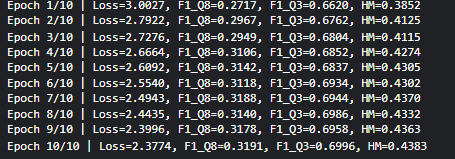

### Train & Validate Bi-GRU Model

In [19]:
'''model_gru = BiGRU().to(device)


optimizer = torch.optim.Adam(model_gru.parameters(), lr=0.0005)

final_loss = train_models(
    model_gru,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=12,
    trackio=trackio
)'''

'model_gru = BiGRU().to(device)\n\n\noptimizer = torch.optim.Adam(model_gru.parameters(), lr=0.0005)\n\nfinal_loss = train_models(\n    model_gru,\n    train_loader,\n    val_loader,\n    optimizer,\n    num_epochs=12,\n    trackio=trackio\n)'

#### Results

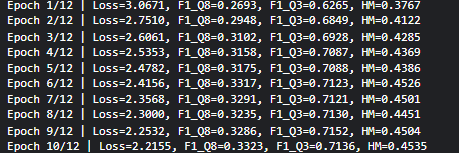

### Train & Validate CNN-LSTM Model

In [20]:
'''model_lstm = CNN_LSTM(
    vocab_size=len(AMINO) + 2,   # PAD + UNK
    embed_dim=128,
    cnn_channels=64,             # per kernel
    hidden=256,
).to(device)

optimizer = torch.optim.AdamW(
    model_lstm.parameters(),
    lr=0.001,          # LR
    weight_decay=1e-4
)

final_loss = train_models(
    model_lstm,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=20,
)'''

'model_lstm = CNN_LSTM(\n    vocab_size=len(AMINO) + 2,   # PAD + UNK\n    embed_dim=128,\n    cnn_channels=64,             # per kernel\n    hidden=256,\n).to(device)\n\noptimizer = torch.optim.AdamW(\n    model_lstm.parameters(),\n    lr=0.001,          # LR\n    weight_decay=1e-4\n)\n\nfinal_loss = train_models(\n    model_lstm,\n    train_loader,\n    val_loader,\n    optimizer,\n    num_epochs=20,\n)'

#### Results

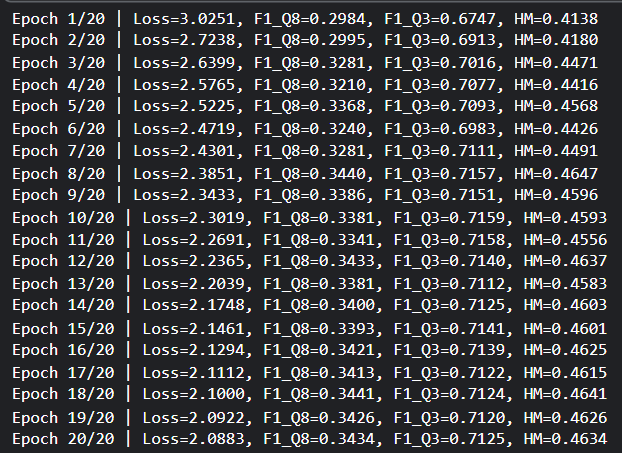

### Saving all models

In [21]:
'''save_dir = Path("./protein_models")
save_dir.mkdir(exist_ok=True)

rnn_model_path = save_dir / "BiRNN.pth"
gru_model_path = save_dir / "BiGRU.pth"
lsm_model_path = save_dir / "LSM.pth"

# Save trained models
torch.save(model_rnn.state_dict(), rnn_model_path)
torch.save(model_gru.state_dict(), gru_model_path)
torch.save(model_lstm.state_dict(), lsm_model_path)

print("Models saved successfully!")'''

'save_dir = Path("./protein_models")\nsave_dir.mkdir(exist_ok=True)\n\nrnn_model_path = save_dir / "BiRNN.pth"\ngru_model_path = save_dir / "BiGRU.pth"\nlsm_model_path = save_dir / "LSM.pth"\n\n# Save trained models\ntorch.save(model_rnn.state_dict(), rnn_model_path)\ntorch.save(model_gru.state_dict(), gru_model_path)\ntorch.save(model_lstm.state_dict(), lsm_model_path)\n\nprint("Models saved successfully!")'

## Uploading Models in Kaggle Hub

In [22]:
'''# for better kaggle score

KAGGLE_USERNAME = 'jatinnahatajain'   #  username
MODEL = 'protein-cnn-lsm'        # model name
FRAMEWORK = 'pytorch'      # framework
VARIATION = 'v1'      # version

model_path = Path("./protein_models")  # folder containing your .pth files

handle = f'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}'

kagglehub.model_upload(
    handle,
    model_path,
    version_notes='Final Protein Model using CNN & LSTM'
)

print("Models uploaded to Kaggle successfully!")'''

'# for better kaggle score\n\nKAGGLE_USERNAME = \'jatinnahatajain\'   #  username\nMODEL = \'protein-cnn-lsm\'        # model name\nFRAMEWORK = \'pytorch\'      # framework\nVARIATION = \'v1\'      # version\n\nmodel_path = Path("./protein_models")  # folder containing your .pth files\n\nhandle = f\'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}\'\n\nkagglehub.model_upload(\n    handle,\n    model_path,\n    version_notes=\'Final Protein Model using CNN & LSTM\'\n)\n\nprint("Models uploaded to Kaggle successfully!")'

In [ ]:
''' # for requirement

KAGGLE_USERNAME = 'jatinnahatajain'   #  username
MODEL = 'protein-rnn-gru'        #  model name
FRAMEWORK = 'pytorch'         # framework
VARIATION = 'baseline'       # baseline version

model_path = Path("./protein_models")  # folder containing your .pth files

handle = f'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}'

kagglehub.model_upload(
    handle,
    model_path,
    version_notes='baseline'
)

print("Models uploaded to Kaggle successfully!")'''

' # for requirement\n\nKAGGLE_USERNAME = \'jatinnahatajain\'   #  username\nMODEL = \'protein-rnn-gru\'        #  model name\nFRAMEWORK = \'pytorch\'         # framework\nVARIATION = \'final\'       # final version\n\nmodel_path = Path("./protein_models")  # folder containing your .pth files\n\nhandle = f\'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}\'\n\nkagglehub.model_upload(\n    handle,\n    model_path,\n    version_notes=\'Final Protein Model using RNN & GRU\'\n)\n\nprint("Models uploaded to Kaggle successfully!")'

## Uploading Models in Kaggle Hub

In [24]:
'''# using for better score on kaggle ~0.487

save_dir = Path("./downloaded_models")
save_dir.mkdir(exist_ok=True)

handle = "jatinnahatajain/protein-cnn-lsm/pytorch/v1"

local_path = kagglehub.model_download(handle, save_dir)

print("Model files downloaded to:", local_path)'''

'# using for better score on kaggle ~0.487\n\nsave_dir = Path("./downloaded_models")\nsave_dir.mkdir(exist_ok=True)\n\nhandle = "jatinnahatajain/protein-cnn-lsm/pytorch/v1"\n\nlocal_path = kagglehub.model_download(handle, save_dir)\n\nprint("Model files downloaded to:", local_path)'

In [ ]:
'''# for requirement (on kaggle ~0.482)

save_dir = Path("./downloaded_models")
save_dir.mkdir(exist_ok=True)

handle = "jatinnahatajain/protein-rnn-gru/pytorch/baseline"

local_path = kagglehub.model_download(handle, save_dir)

print("Model files downloaded to:", local_path)'''

'# for requirement (on kaggle ~0.482)\n\nsave_dir = Path("./downloaded_models")\nsave_dir.mkdir(exist_ok=True)\n\nhandle = "jatinnahatajain/protein-rnn-gru/pytorch/final"\n\nlocal_path = kagglehub.model_download(handle, save_dir)\n\nprint("Model files downloaded to:", local_path)'

## Downloading Models from Kaggle Hub

In [ ]:
'''device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gru = BiGRU().to(device)

# Load saved state dict
model_gru.load_state_dict(
    torch.load("/kaggle/input/protein-rnn-gru/pytorch/baseline/1/BiGRU.pth", map_location=device))

model_gru.eval()
print("BiGRU model loaded!")'''

'device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nmodel_gru = BiGRU().to(device)\n\n# Load saved state dict\nmodel_gru.load_state_dict(\n    torch.load("/kaggle/input/protein-rnn-gru/pytorch/final/2/BiGRU.pth", map_location=device))\n\nmodel_gru.eval()\nprint("BiGRU model loaded!")'

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm = CNN_LSTM(
    vocab_size=len(AMINO) + 2,   # PAD + UNK
    embed_dim=128,
    cnn_channels=64,   # per kernel
    hidden=256,
).to(device)

# Load saved state dict
model_lstm.load_state_dict(
    torch.load("/kaggle/input/protein-cnn-lsm/pytorch/v1/2/LSM.pth", map_location=device))

model_lstm.eval()
print("CNN-LSM model loaded!")

CNN-LSM model loaded!


### Test Data Preparation and Loading

In [28]:
test_dataset = ProteinDataset(test, is_test=True)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

## Submission Notebook in Kaggle

In [29]:
# Submission with BiGRU
'''submission = []

model_gru.eval()

with torch.no_grad():
    for batch in test_loader:
        seqs, _, _, lengths, ids = batch
        seqs = seqs.to(device)

        out3, out8 = model_gru(seqs)

        p8 = out8.argmax(-1).cpu().numpy()
        p3 = out3.argmax(-1).cpu().numpy()

        for i, seq_id in enumerate(ids):
            L = lengths[i]

            pred_q8 = "".join(Q8[x] for x in p8[i][:L])
            pred_q3 = "".join(Q3[x] for x in p3[i][:L])

            submission.append({
                "id": int(seq_id),
                "sst8": pred_q8,
                "sst3": pred_q3
            })

submission_df = pd.DataFrame(submission)
submission_df.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(submission_df.head())'''

'submission = []\n\nmodel_gru.eval()\n\nwith torch.no_grad():\n    for batch in test_loader:\n        seqs, _, _, lengths, ids = batch\n        seqs = seqs.to(device)\n\n        out3, out8 = model_gru(seqs)\n\n        p8 = out8.argmax(-1).cpu().numpy()\n        p3 = out3.argmax(-1).cpu().numpy()\n\n        for i, seq_id in enumerate(ids):\n            L = lengths[i]\n\n            pred_q8 = "".join(Q8[x] for x in p8[i][:L])\n            pred_q3 = "".join(Q3[x] for x in p3[i][:L])\n\n            submission.append({\n                "id": int(seq_id),\n                "sst8": pred_q8,\n                "sst3": pred_q3\n            })\n\nsubmission_df = pd.DataFrame(submission)\nsubmission_df.to_csv("submission.csv", index=False)\n\nprint("Saved submission.csv")\nprint(submission_df.head())'

In [30]:
# Submission with CNN-LSTM
submission = []

model_lstm.eval()

with torch.no_grad():
    for batch in test_loader:
        seqs, _, _, lengths, ids = batch
        seqs = seqs.to(device)

        out3, out8 = model_lstm(seqs)

        p8 = out8.argmax(-1).cpu().numpy()
        p3 = out3.argmax(-1).cpu().numpy()

        for i, seq_id in enumerate(ids):
            L = lengths[i]

            pred_q8 = "".join(Q8[x] for x in p8[i][:L])
            pred_q3 = "".join(Q3[x] for x in p3[i][:L])

            submission.append({
                "id": int(seq_id),
                "sst8": pred_q8,
                "sst3": pred_q3
            })

submission_df = pd.DataFrame(submission)
submission_df.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(submission_df.head())

Saved submission.csv
   id                                               sst8  \
0   0  CCCCHHHHHHHHHHHHHHHHHHHCEEEEEEECTCTTCCEEEEEECT...   
1   1  CCCCCCCCCCEEEEEEECSTTCEEEEEECTTHHHHHHHCCCCTHHH...   
2   2  CTHHHHHHHHHHHHHHHHHHTHHHHHHHHHHHHHHCCTTHHHHHHH...   
3   3  CCCTTHHHHHHHHHHHHHHHHHHHHHHHCCEEEEETTHHHHHHHHH...   
4   4  CEEEEEEGCCCTHHHHHHHHHHHHHHHCCEEEECSTTCEEEECSEE...   

                                                sst3  
0  CCCCCHHHHHHHHHHHHHHHHHHCEEEEEEECCCCCCCCEEEEECC...  
1  CCCCCCCCCCEEEEEEECCCCCEEEEEECCCHHHHHHCCCCCCCHH...  
2  CCHHHHHHHHHHHHHHHHHCHHHHHHHHHHHHHHHCCCCCHHHHHH...  
3  CCCCCHHHHHHHHHHHHHHHHHHHHHHHCCEEEECCCHHHHHHHHH...  
4  CEEEEEECCCCCHHHHHHHHHHHHHHHCCEEEECCCCCEEEECCEE...  
